Tesseract found at: /usr/bin/tesseract
Connection was successful

Detected Text             | Confidence Score   | Status    
ARTIFICIAL                |             95.00% | PASSED    
INTELLIGENCE              |             95.00% | PASSED    
Attificial                |             83.00% | PASSED    
Intelligence              |             95.00% | PASSED    
(Al)                      |             83.00% | PASSED    
is                        |             94.00% | PASSED    
2                         |             65.00% | FAILED (<80%)
branch                    |             96.00% | PASSED    
of                        |             96.00% | PASSED    
computer                  |             96.00% | PASSED    
science                   |             96.00% | PASSED    
that                      |             96.00% | PASSED    
enables                   |             96.00% | PASSED    
machines                  |             96.00% | PASSED    
to                        |    

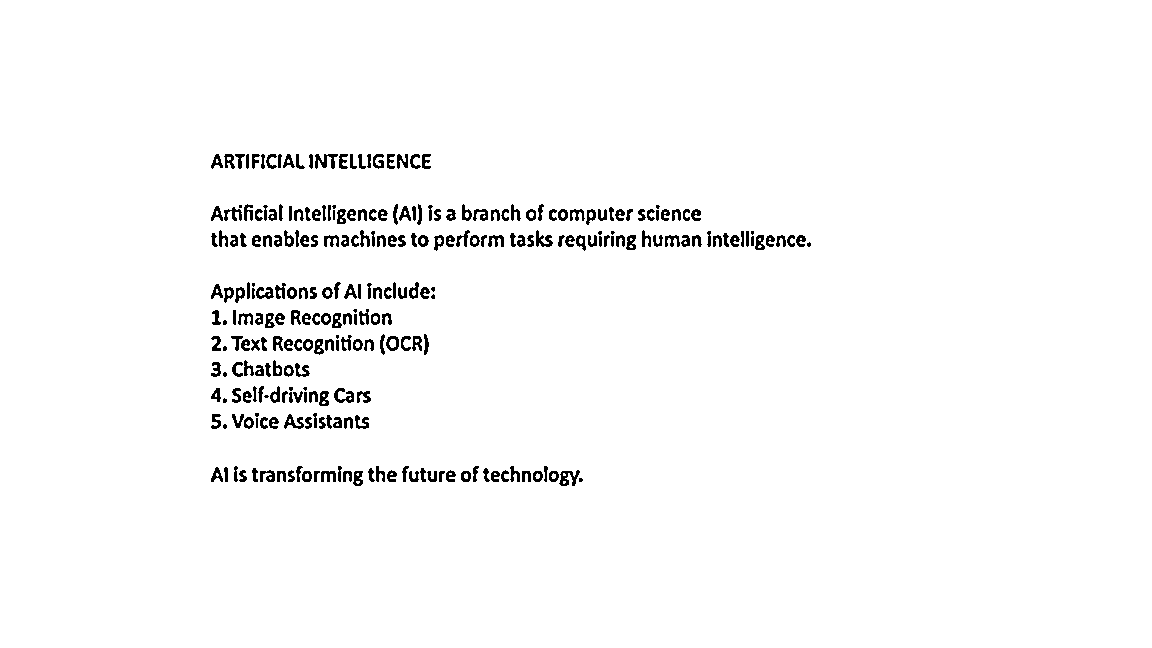


--- Final Visual Confirmation (Resized Output) ---


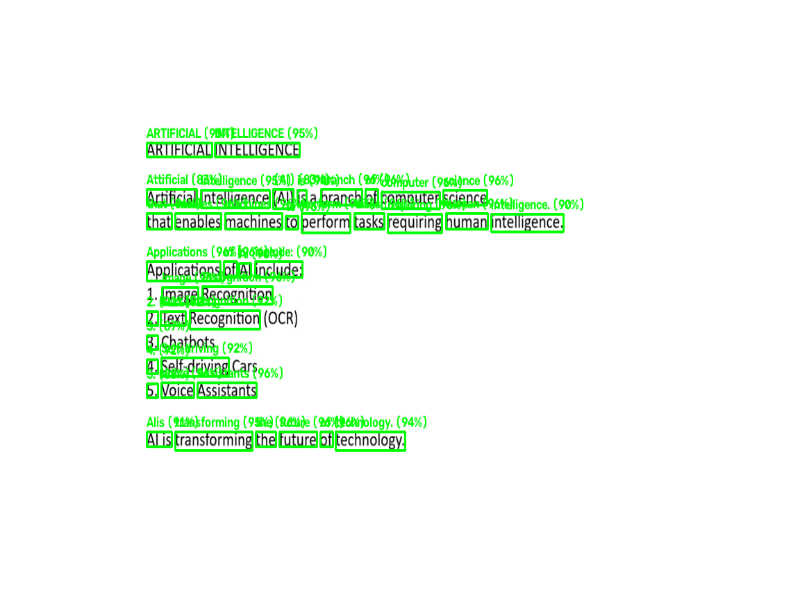

In [3]:
import os
import shutil
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import pytesseract
from pytesseract import Output

image_path = "sample.jpg"

if shutil.which("tesseract") is None:
    print("Error: Tesseract is not installed or not in PATH")
else:
    print("Tesseract found at:", shutil.which("tesseract"))
    print("Connection was successful\n")

    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image at path: '{image_path}'.")

    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    hig, wid, _ = img.shape

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    adaptive_thresh = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=11,
        C=2,
    )

    ocr_data = pytesseract.image_to_data(adaptive_thresh, output_type=Output.DICT)

    print("=" * 65)
    print(f"{'Detected Text':<25} | {'Confidence Score':<18} | {'Status':<10}")
    print("=" * 65)

    n_boxes = len(ocr_data["text"])
    for i in range(n_boxes):
        text = ocr_data["text"][i].strip()

        try:
            conf = float(ocr_data["conf"][i])
        except (ValueError, TypeError):
            conf = -1.0

        if not text or conf < 0:
            continue

        if conf >= 80.0:
            status = "PASSED"
            x, y, w, h = (ocr_data["left"][i],ocr_data["top"][i],ocr_data["width"][i],ocr_data["height"][i])
            cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(
                img,
                f"{text} ({int(conf)}%)",
                (x, max(y - 5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2,
            )
        else:
            status = "FAILED (<80%)"

        print(f"{text:<25} | {conf:>17.2f}% | {status:<10}")

    print("=" * 65)
    print("\n--- Pre-processed (Adaptive Threshold) Image ---")
    cv2_imshow(adaptive_thresh)

    print("\n--- Final Visual Confirmation (Resized Output) ---")
    final_output = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    resized_img = cv2.resize(final_output, (800, 600))

    cv2_imshow(resized_img)